# Hadamard with spectral leakage proxy

Adds a custom DirectTrajOpt objective that penalizes |Ω̂(η)|² — the Fourier coefficient of the complex drive envelope at the |1⟩↔|2⟩ leakage transition frequency.

Leading-order TDPT gives c₂(T) ≈ -i·√2·Ω̂(η), so |c₂|² ≈ 2·|Ω̂(η)|². Minimizing |Ω̂(η)|² as a 2-lvl optimization cost suppresses leakage *to leading order* without ever leaving the qubit subspace. The 3-lvl model is used only for verification.

Four variants are optimized:
- Default — Q_r = 0, R_leak = 0 (baseline)
- Robust  — Q_r > 0, R_leak = 0 (σ_z-robust baseline)
- Default + spectral — Q_r = 0, R_leak > 0
- Robust  + spectral — Q_r > 0, R_leak > 0

For each: time-domain controls, frequency-domain |Ω̂(f)|, 2-lvl unitary_rollout F, 2-lvl QuantumToolbox F (cross-check), 3-lvl F + leakage at gate end, plus the F vs ε σ_z-robustness sweep.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
piccolo_path       = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop([
    Pkg.PackageSpec(path = piccolo_path),
    Pkg.PackageSpec(path = directtrajopt_path),
])
Pkg.add(["CairoMakie", "MathTeXEngine", "LaTeXStrings", "JLD2",
         "DataInterpolations", "Ipopt", "QuantumToolbox", "Statistics", "FFTW"])
Pkg.instantiate()

using Piccolo
using LinearAlgebra, Random, Printf, Statistics, JLD2
using CairoMakie, MathTeXEngine, LaTeXStrings
using DataInterpolations: CubicHermiteSpline
using SparseArrays
using FFTW

import DirectTrajOpt.Objectives: AbstractObjective, objective_value, gradient!, hessian_structure, get_full_hessian
# TrajectoryIndexingUtils is bundled via Piccolo; we inline the formula `dim*(k-1) + pos` below.
# get_times, get_timesteps come via `using Piccolo` (which re-exports NamedTrajectories).

set_theme!(Theme(
    fonts = (;
        regular = texfont(:text), bold = texfont(:bold),
        italic = texfont(:italic), bold_italic = texfont(:bolditalic),
        ticks = "TeX Gyre Heros Makie",
    ),
    Axis = (; xgridvisible = false),
))

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Manifest.toml`


## Parameters & operators

In [2]:
# ---- Gate / system parameters (same as hadamard_alc_comparison.ipynb) ----
const T_NS        = 50.0
const a_bound     = 2π * 0.01            # 10 MHz drive bound
const η_anh       = -2π * 0.170          # -170 MHz anharmonicity (transmon)
const δ_ALC       = η_anh                # |1⟩↔|2⟩ angular frequency
const F_THRESHOLD = 0.9999
const N_KNOTS     = 20
const Δt_GATE     = T_NS / (N_KNOTS - 1)
const Q_R_DEFAULT = 0.0
const Q_R_ROBUST  = 1000.0
const R_DDU       = 30.0
const DDU_BOUND   = 1.0
const R_LEAK      = 1e6                  # spectral leakage proxy weight (tune)
const NUM_ITER    = 1500
const SEED        = 42

# 2-level operators
const σx = ComplexF64[0  1; 1  0]
const σy = ComplexF64[0 -im; im 0]
const σz = ComplexF64[1  0; 0 -1]
const I2 = Matrix{ComplexF64}(I, 2, 2)

# 3-level operators (Duffing)
const I3     = Matrix{ComplexF64}(I, 3, 3)
const a3     = ComplexF64[0 1 0; 0 0 sqrt(2); 0 0 0]
const ad3    = adjoint(a3)
const X3     = a3 + ad3
const Y3     = im * (ad3 - a3)
const n3     = ad3 * a3
const H_anh3 = (η_anh / 2) * n3 * (n3 - I3)
const subspace_indices = [1, 2]

const U_target = (1/sqrt(2)) * ComplexF64[1.0  1.0; 1.0 -1.0]
const MHz_per_radperns = 1e3 / (2π)

@printf("T = %.1f ns,  η = %.1f MHz,  N_knots = %d,  R_leak = %.0e\n",
    T_NS, η_anh/(2π)*1e3, N_KNOTS, R_LEAK)

T = 50.0 ns,  η = -170.0 MHz,  N_knots = 20,  R_leak = 1e+06


## Custom `SpectralLeakageObjective`

Defined locally so we don't touch the Piccolo source. Penalizes `R · |Ω̂(ω)|²` where Ω̂(ω) = Σ_k Δt_k · (u_X[k] + i·u_Y[k]) · exp(-i·ω·t_k). Analytic gradient; Hessian is a dense 2N×2N block (sparse pattern marked correctly so Ipopt can handle it; with `eval_hessian=false` it's never actually used).

In [3]:
struct SpectralLeakageObjective <: AbstractObjective
    name::Symbol                    # control variable (expected to be 2 components: u_X, u_Y)
    R::Float64                      # regularization weight
    ω::Float64                      # angular frequency to suppress (rad/ns)
    times::Vector{Float64}          # cached knot times (only valid for fixed Δt)
    Δts::Vector{Float64}            # cached timesteps
    cosωt::Vector{Float64}
    sinωt::Vector{Float64}
end

function SpectralLeakageObjective(name::Symbol, ω::Float64, R::Float64, traj::NamedTrajectory)
    @assert traj.dims[name] == 2 "SpectralLeakageObjective expects 2 components (u_X, u_Y)."
    times = get_times(traj)
    Δts   = get_timesteps(traj)
    return SpectralLeakageObjective(name, R, ω,
        Vector{Float64}(times), Vector{Float64}(Δts),
        cos.(ω .* times), sin.(ω .* times))
end

function objective_value(obj::SpectralLeakageObjective, traj::NamedTrajectory)
    u = traj[obj.name]
    Re_sum = 0.0; Im_sum = 0.0
    @inbounds for k in 1:length(obj.times)
        c = obj.cosωt[k]; s = obj.sinωt[k]; Δt = obj.Δts[k]
        Re_sum += Δt * (u[1, k] * c + u[2, k] * s)
        Im_sum += Δt * (u[2, k] * c - u[1, k] * s)
    end
    return obj.R * (Re_sum^2 + Im_sum^2)
end

function gradient!(∇::AbstractVector, obj::SpectralLeakageObjective, traj::NamedTrajectory)
    u = traj[obj.name]
    N = length(obj.times)
    Re_sum = 0.0; Im_sum = 0.0
    @inbounds for k in 1:N
        c = obj.cosωt[k]; s = obj.sinωt[k]; Δt = obj.Δts[k]
        Re_sum += Δt * (u[1, k] * c + u[2, k] * s)
        Im_sum += Δt * (u[2, k] * c - u[1, k] * s)
    end
    comps = traj.components[obj.name]
    @inbounds for k in 1:N
        c = obj.cosωt[k]; s = obj.sinωt[k]; Δt = obj.Δts[k]
        idxX = traj.dim * (k - 1) + comps[1]
        idxY = traj.dim * (k - 1) + comps[2]
        # ∂L/∂u_X[k] = 2R·Δt_k·(Re_sum·c - Im_sum·s)
        # ∂L/∂u_Y[k] = 2R·Δt_k·(Re_sum·s + Im_sum·c)
        ∇[idxX] += 2 * obj.R * Δt * (Re_sum * c - Im_sum * s)
        ∇[idxY] += 2 * obj.R * Δt * (Re_sum * s + Im_sum * c)
    end
    return nothing
end

function hessian_structure(obj::SpectralLeakageObjective, traj::NamedTrajectory)
    Z_dim = traj.dim * traj.N + traj.global_dim
    structure = spzeros(Z_dim, Z_dim)
    comps = traj.components[obj.name]
    idxs = Int[]
    for k in 1:traj.N
        push!(idxs, traj.dim * (k - 1) + comps[1])
        push!(idxs, traj.dim * (k - 1) + comps[2])
    end
    for i in idxs, j in idxs
        structure[i, j] = 1.0
    end
    return structure
end

function get_full_hessian(obj::SpectralLeakageObjective, traj::NamedTrajectory)
    Z_dim = traj.dim * traj.N + traj.global_dim
    ∂²L = spzeros(Z_dim, Z_dim)
    comps = traj.components[obj.name]
    # L = R · (a^T x)² + R · (b^T x)² where x = control vector restricted to (u_X, u_Y) knots.
    # Hessian = 2R · (a aᵀ + b bᵀ).
    N = traj.N
    a = zeros(Z_dim); b = zeros(Z_dim)
    for k in 1:N
        c = obj.cosωt[k]; s = obj.sinωt[k]; Δt = obj.Δts[k]
        idxX = traj.dim * (k - 1) + comps[1]
        idxY = traj.dim * (k - 1) + comps[2]
        a[idxX] += Δt * c;  a[idxY] += Δt * s
        b[idxX] -= Δt * s;  b[idxY] += Δt * c
    end
    nzs = findall(!iszero, a) ∪ findall(!iszero, b)
    for i in nzs, j in nzs
        v = 2 * obj.R * (a[i]*a[j] + b[i]*b[j])
        if v != 0.0
            ∂²L[i, j] = v
        end
    end
    return ∂²L
end

println("SpectralLeakageObjective defined.")

SpectralLeakageObjective defined.


## 4-way optimization

In [4]:
function optimize_2lvl(; robust::Bool, with_proxy::Bool, seed::Int = SEED)
    Random.seed!(seed)
    drive_bounds = fill(a_bound, 2)
    H_fn      = (u, t) -> u[1] * σx + u[2] * σy
    H_vars_fn = Function[(u, t) -> σz]
    varsys = VariationalQuantumSystem(
        H_fn, H_vars_fn, 2, drive_bounds; time_dependent = true)

    times_knots   = collect(range(0.0, T_NS, length = N_KNOTS))
    controls_init = 0.1 .* a_bound .* randn(2, N_KNOTS)
    pulse         = CubicSplinePulse(controls_init, times_knots)

    Q_r = robust ? Q_R_ROBUST : Q_R_DEFAULT

    qcp = VariationalSplinePulseProblem(
        varsys, pulse, U_target;
        Q              = 0.0,
        Q_r            = Q_r,
        R              = 1e-3,
        R_ddu          = R_DDU,
        du_bound       = Inf,
        ddu_bound      = DDU_BOUND,
        Δt_bounds      = (Δt_GATE, Δt_GATE),
        n_path_samples = 3,
    )
    push!(qcp.prob.constraints,
        FinalUnitaryFidelityConstraint(U_target, :Ũ⃗, F_THRESHOLD, get_trajectory(qcp)))

    # Spectral leakage proxy on :u — adds R · |Ω̂(η)|² to the cost.
    if with_proxy
        spec_obj = SpectralLeakageObjective(:u, abs(η_anh), R_LEAK, get_trajectory(qcp))
        qcp.prob.objective = qcp.prob.objective + spec_obj
    end

    label = (robust ? "ROBUST" : "DEFAULT") * (with_proxy ? " + SPECTRAL" : "")
    println("\n--- $label optimization ---")
    t0 = time()
    solve!(qcp; max_iter = NUM_ITER, print_level = 0,
        options = IpoptOptions(
            eval_hessian = false, constr_viol_tol = 1e-8,
            tol = 1e-8, acceptable_tol = 1e-8,
        ))
    @printf("solve wall: %.1f s\n", time() - t0)

    return get_trajectory(qcp)
end

# Only the with-proxy runs (per user request).
traj_d_prox = optimize_2lvl(; robust = false, with_proxy = true)
traj_r_prox = optimize_2lvl(; robust = true,  with_proxy = true)
println("\nBoth proxy-optimized pulses ready.")


    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 1
      added augmented state :var_Ũ⃗  dim=16  (1 error channels)
      dynamics spline order: 3
      added DerivativeIntegrator (:du → :ddu) for acceleration bound
      applying TimeStepsAllEqualConstraint
      added CubicHermitePathConstraint: 3 samples/interval, bound=±0.06283

--- DEFAULT + SPECTRAL optimization ---
    initializing optimizer...
      building evaluator: 3 integrators, 2 nonlinear constraints
      dynamics constraints: 494, nonlinear constraints: 229
        integrator 1 jacobian structure: 0.114s
        integrator 2 jacobian structure: 0.008s
        integrator 3 jacobian structure: 0.008s
        constraint 1 (CubicHermitePathConstraint) jacobian structure: 0.552s
        constraint 2 (NonlinearKnot

## Time-domain controls

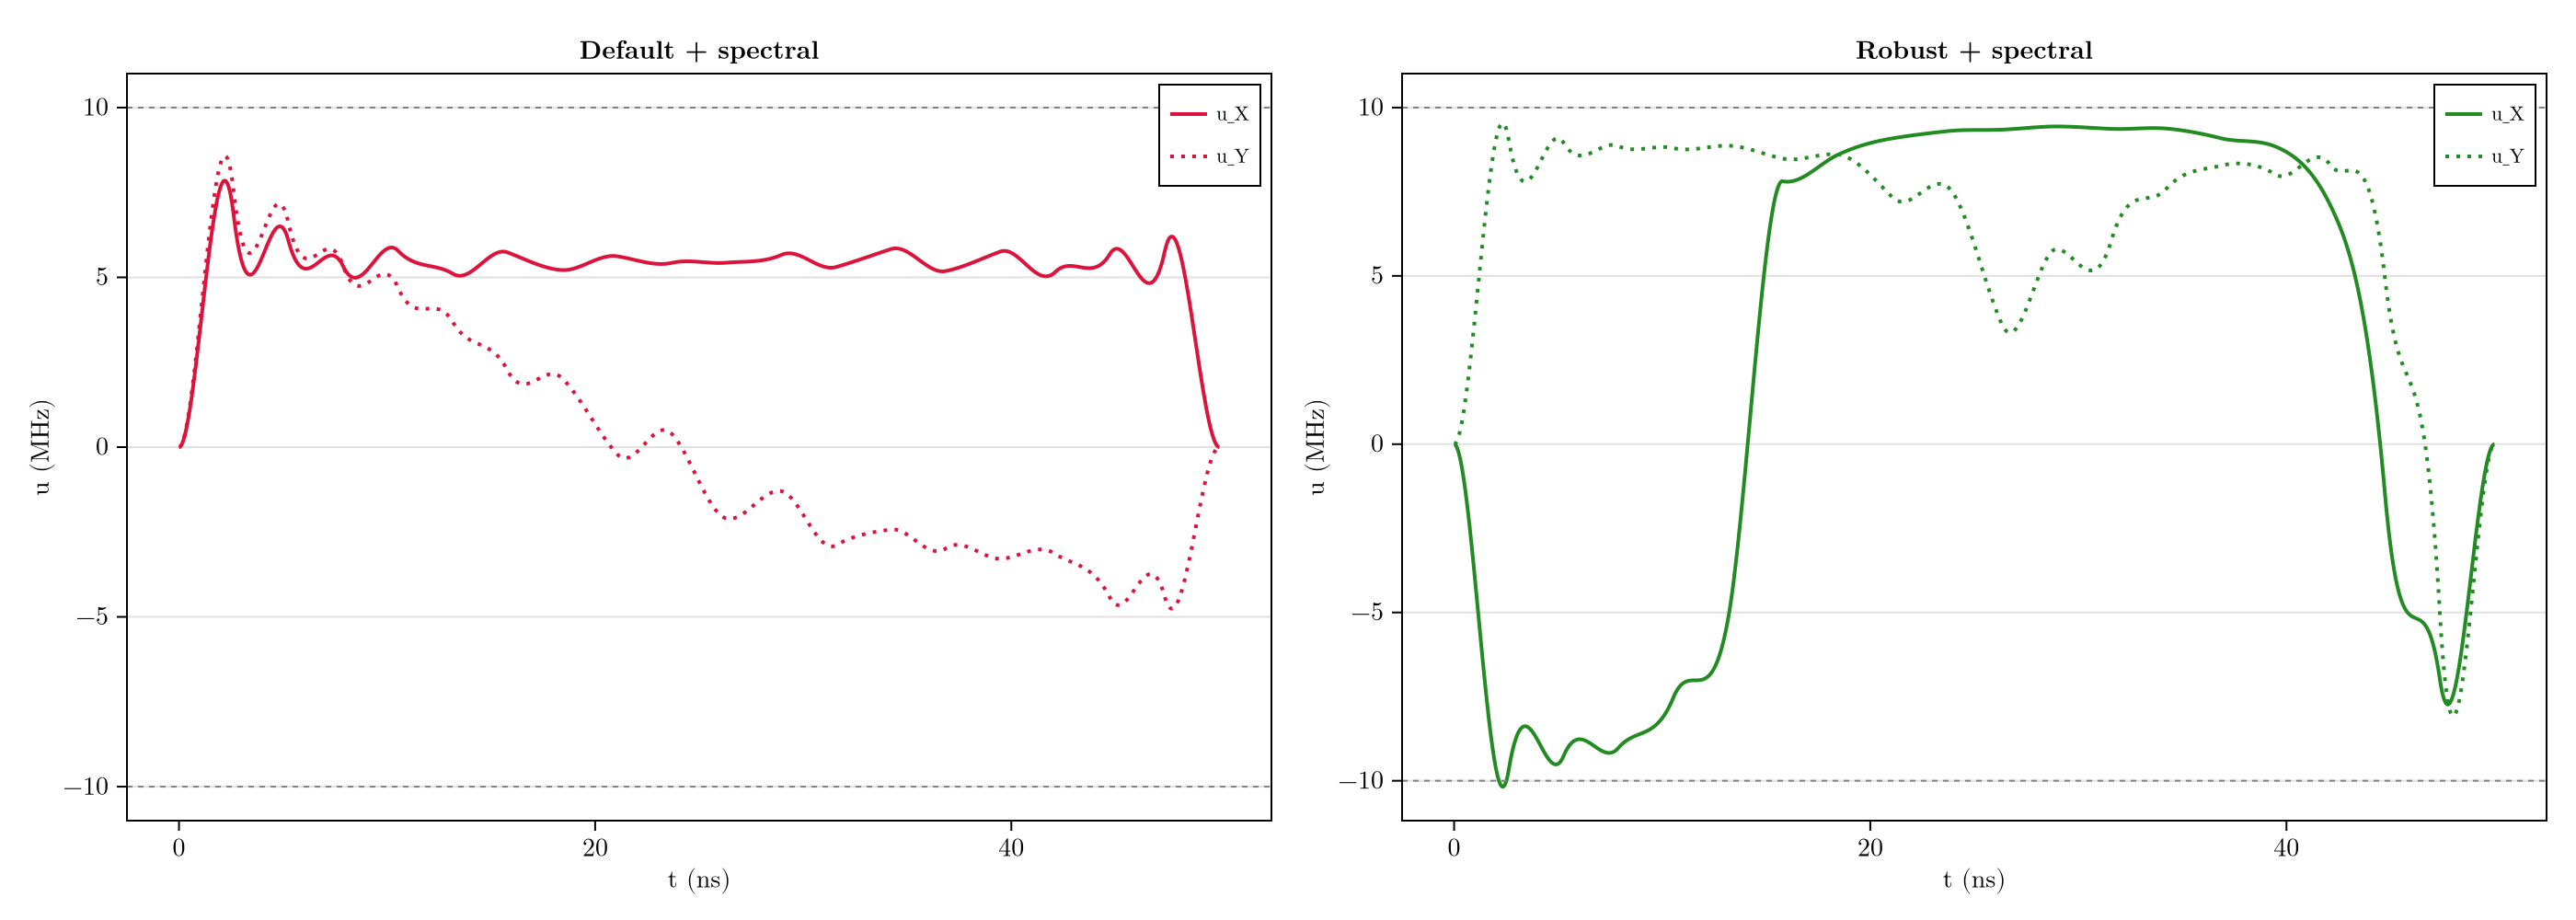

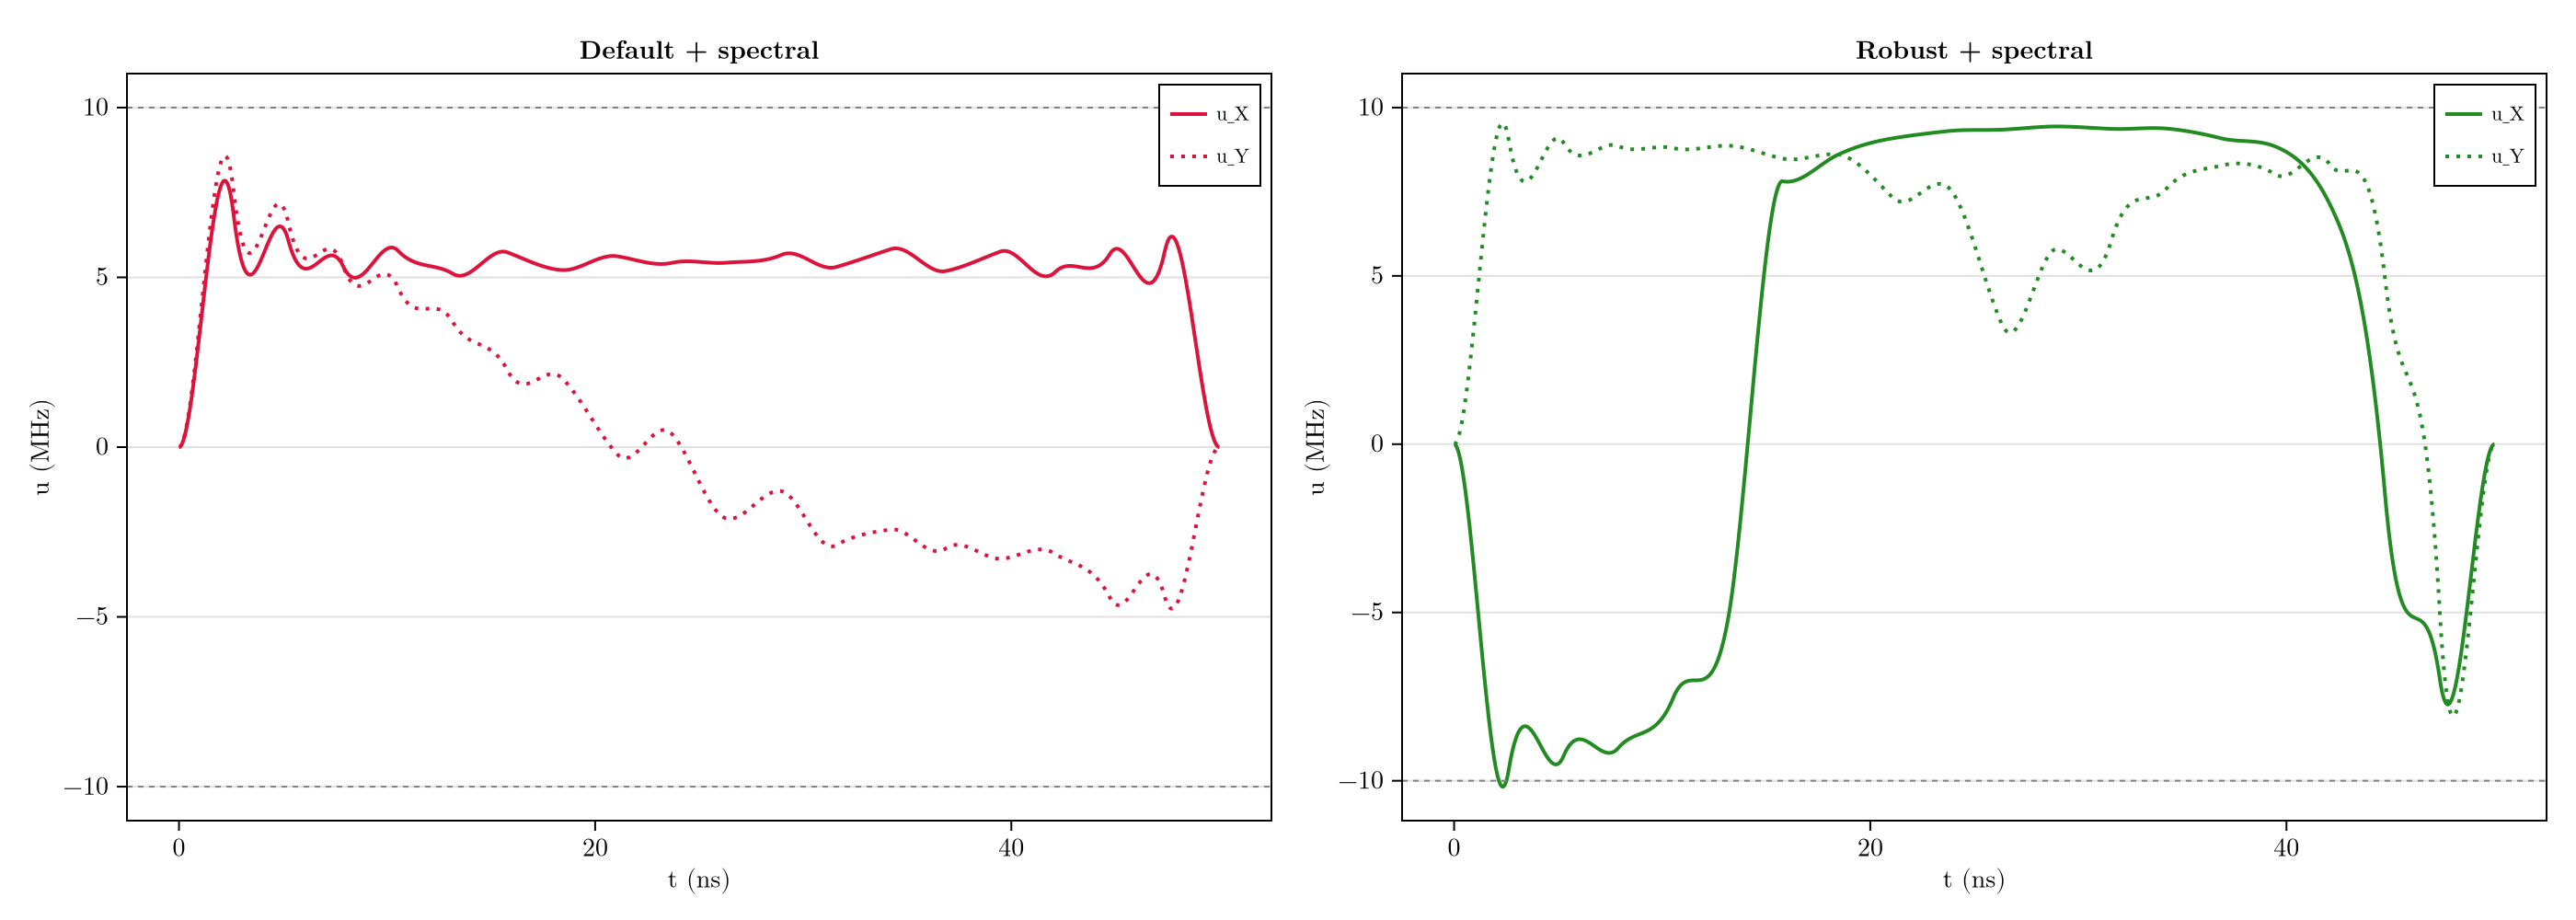

In [5]:
function spline_uXuY(traj)
    us  = traj[:u]; dus = traj[:du]
    ts  = collect(range(0.0, T_NS, length = size(us, 2)))
    return CubicHermiteSpline(dus[1, :], us[1, :], ts),
           CubicHermiteSpline(dus[2, :], us[2, :], ts)
end

ts_fine = collect(range(0.0, T_NS, length = 2000))

function sample_pulse(traj)
    sp_X, sp_Y = spline_uXuY(traj)
    return ([sp_X(t) for t in ts_fine] .* MHz_per_radperns,
            [sp_Y(t) for t in ts_fine] .* MHz_per_radperns)
end

panels = [
    ("Default + spectral", traj_d_prox, :crimson),
    ("Robust + spectral",  traj_r_prox, :forestgreen),
]

fig = Figure(size = (1400, 500), fontsize = 14)
for (i, (lbl, traj, c)) in enumerate(panels)
    ax = Axis(fig[1, i]; xlabel = "t (ns)", ylabel = "u (MHz)", title = lbl)
    uX, uY = sample_pulse(traj)
    lines!(ax, ts_fine, uX; color = c, linewidth = 2.0, label = "u_X")
    lines!(ax, ts_fine, uY; color = c, linewidth = 2.0, linestyle = :dot, label = "u_Y")
    hlines!(ax, [a_bound, -a_bound] .* MHz_per_radperns;
        color = :gray, linestyle = :dash, linewidth = 1)
    axislegend(ax; position = :rt, labelsize = 11)
end
display(fig)
save(joinpath(@__DIR__, "spectral_time_domain.png"), fig; px_per_unit = 4)
fig


## Frequency-domain: |Ω̂(f)|

Dashed vertical line is the leakage transition frequency f₂₁ − f₁₀ = η/(2π). The spectral proxy should push the |Ω̂| value at that frequency much lower.

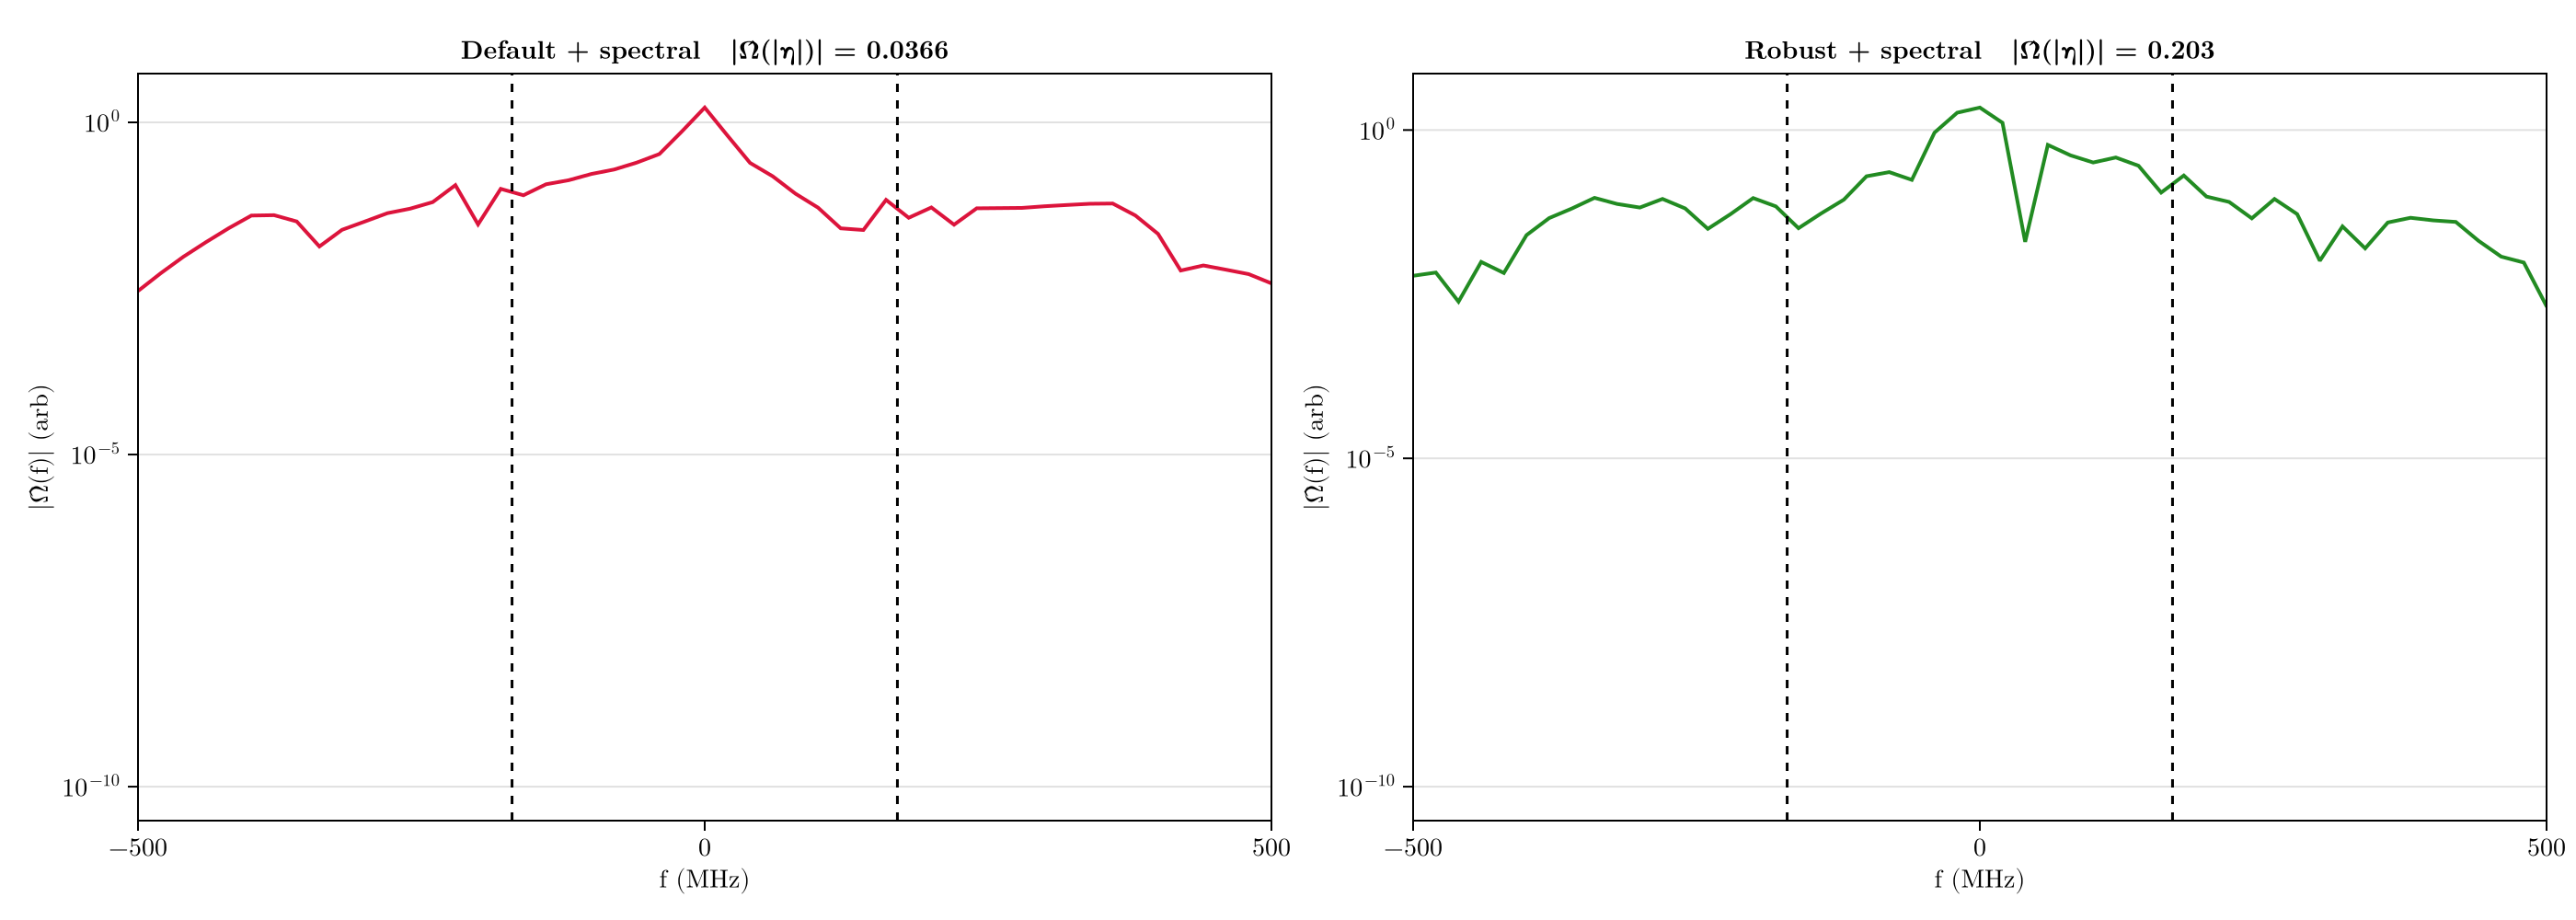

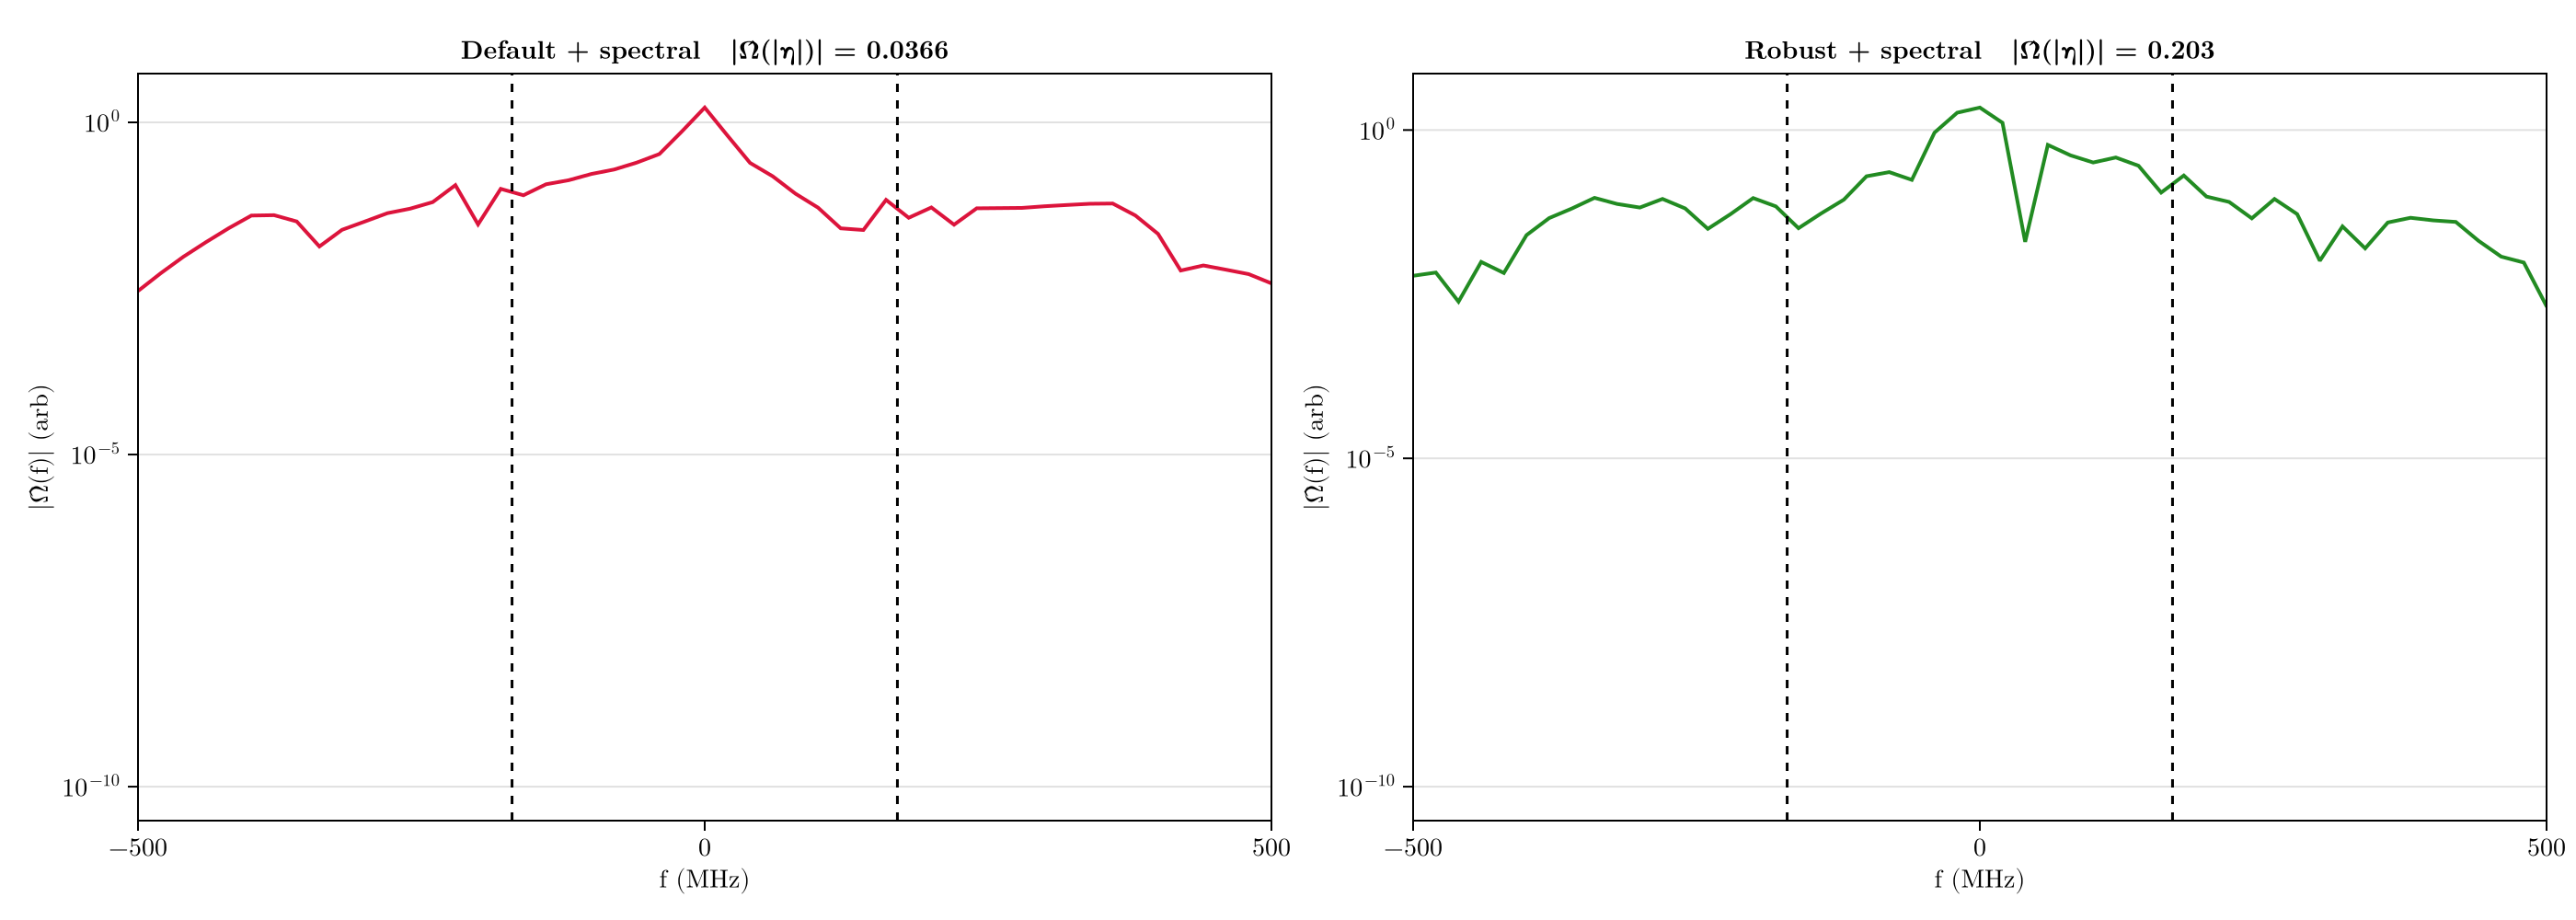

In [6]:
function envelope_spectrum(traj; N_dense = 8192)
    sp_X, sp_Y = spline_uXuY(traj)
    ts_d = collect(range(0.0, T_NS, length = N_dense))
    dt_d = ts_d[2] - ts_d[1]
    Ω = [sp_X(t) + im * sp_Y(t) for t in ts_d]
    Ω̂ = fftshift(fft(Ω)) * dt_d
    fs = fftshift(fftfreq(N_dense, 1/dt_d))    # GHz (since t in ns → 1/ns)
    return fs .* 1e3, abs.(Ω̂)                  # MHz, |Ω̂|
end

η_MHz = η_anh / (2π) * 1e3

fig = Figure(size = (1400, 500), fontsize = 14)
for (i, (lbl, traj, c)) in enumerate(panels)
    fs_MHz, mag = envelope_spectrum(traj)
    Ω_at_η = mag[argmin(abs.(fs_MHz .- abs(η_MHz)))]
    ax = Axis(fig[1, i];
        xlabel = "f (MHz)", ylabel = "|Ω̂(f)| (arb)",
        yscale = log10,
        title = "$(lbl)   |Ω̂(|η|)| = $(round(Ω_at_η, sigdigits=3))")
    lines!(ax, fs_MHz, max.(mag, 1e-10); color = c, linewidth = 2.0)
    vlines!(ax, [η_MHz, -η_MHz]; color = :black, linestyle = :dash, linewidth = 1.5)
    xlims!(ax, -500, 500)
end
display(fig)
save(joinpath(@__DIR__, "spectral_freq_domain.png"), fig; px_per_unit = 4)
fig


## 2-lvl honest verification (`unitary_rollout`, cubic-Hermite spline)

In [7]:
const sys_2lvl = QuantumSystem(zeros(ComplexF64, 2, 2), [σx, σy], fill(a_bound, 2))

function honest_F_2lvl(traj)
    Ũ⃗ = unitary_rollout(traj, sys_2lvl;
        interpolation = :cubic_hermite, abstol = 1e-12, reltol = 1e-12)
    U_T = iso_vec_to_operator(Ũ⃗[:, end])
    return abs2(tr(U_target' * U_T)) / 4
end

for (lbl, traj, _) in panels
    @printf("%-24s  F_2lvl = %.6f\n", lbl, honest_F_2lvl(traj))
end

Default + spectral        F_2lvl = 0.999886
Robust + spectral         F_2lvl = 0.999336


## 2-lvl QuantumToolbox cross-check (independent ODE solver)

In [8]:
using QuantumToolbox
import QuantumToolbox: Qobj, QobjEvo, sesolve, basis

const σx_qt = Qobj(σx)
const σy_qt = Qobj(σy)
const σz_qt = Qobj(σz)

function F_QT_2lvl(traj; ε = 0.0)
    sp_X, sp_Y = spline_uXuY(traj)
    coef_x = (p, t) -> sp_X(t)
    coef_y = (p, t) -> sp_Y(t)
    H = QobjEvo((ε * σz_qt, (σx_qt, coef_x), (σy_qt, coef_y)))
    U_T = Matrix{ComplexF64}(I, 2, 2)
    for ψ0_idx in 0:1
        ψ0 = basis(2, ψ0_idx)
        sol = sesolve(H, ψ0, [0.0, T_NS]; progress_bar = Val(false),
                      abstol = 1e-12, reltol = 1e-12)
        U_T[:, ψ0_idx + 1] = sol.states[end].data
    end
    return abs2(tr(U_target' * U_T)) / 4
end

for (lbl, traj, _) in panels
    F_pr = honest_F_2lvl(traj)
    F_qt = F_QT_2lvl(traj)
    @printf("%-24s  F_rollout = %.6f   F_QT = %.6f   |Δ| = %.2e\n",
        lbl, F_pr, F_qt, abs(F_pr - F_qt))
end

Default + spectral        F_rollout = 0.999886   F_QT = 0.999886   |Δ| = 1.12e-10
Robust + spectral         F_rollout = 0.999336   F_QT = 0.999336   |Δ| = 1.41e-10


## 3-lvl simulation at ε = 0 (honest leakage check)

In [9]:
function propagate_3lvl_raw(traj, ε; N_fine = 1000)
    sp_X, sp_Y = spline_uXuY(traj)
    ts_f = collect(range(0.0, T_NS, length = N_fine))
    dt_sub = ts_f[2] - ts_f[1]
    U = Matrix{ComplexF64}(I, 3, 3)
    for k in 1:N_fine - 1
        t_mid = 0.5 * (ts_f[k] + ts_f[k+1])
        H = H_anh3 + sp_X(t_mid) * X3 + sp_Y(t_mid) * Y3 + ε * n3
        U = exp(-im * dt_sub * H) * U
    end
    return U
end

function F_L_3lvl(traj; ε = 0.0)
    U_T  = propagate_3lvl_raw(traj, ε)
    Usub = U_T[subspace_indices, subspace_indices]
    F = abs2(tr(U_target' * Usub)) / 4
    L = 1 - real(tr(Usub' * Usub)) / 2
    return F, L
end

for (lbl, traj, _) in panels
    F3, L3 = F_L_3lvl(traj)
    @printf("%-24s  F_3lvl = %.6f   L_3lvl = %.3e\n", lbl, F3, L3)
end

Default + spectral        F_3lvl = 0.996256   L_3lvl = 9.068e-04
Robust + spectral         F_3lvl = 0.973782   L_3lvl = 2.054e-02


## ε-sweep — robustness curves (2-lvl & 3-lvl)

In [10]:
εs = collect(range(-2π*0.010, 2π*0.010, length = 51))   # ±10 MHz in rad/ns
εs_MHz = εs .* MHz_per_radperns

function sweep_2lvl(traj)
    Fs = Float64[]
    for ε in εs
        sys_pert = QuantumSystem(ε * σz, [σx, σy], fill(a_bound, 2))
        Ũ⃗ = unitary_rollout(traj, sys_pert;
            interpolation = :cubic_hermite, abstol = 1e-12, reltol = 1e-12)
        U_T = iso_vec_to_operator(Ũ⃗[:, end])
        push!(Fs, abs2(tr(U_target' * U_T)) / 4)
    end
    return Fs
end

function sweep_3lvl(traj)
    Fs = Float64[]; Ls = Float64[]
    for ε in εs
        F, L = F_L_3lvl(traj; ε = ε)
        push!(Fs, F); push!(Ls, L)
    end
    return Fs, Ls
end

println("Running 2-lvl ε-sweeps...")
@time F2_dp = sweep_2lvl(traj_d_prox);
@time F2_rp = sweep_2lvl(traj_r_prox);

println("Running 3-lvl ε-sweeps...")
@time F3_dp, L3_dp = sweep_3lvl(traj_d_prox);
@time F3_rp, L3_rp = sweep_3lvl(traj_r_prox);

println("Done.")


Running 2-lvl ε-sweeps...
  2.301522 seconds (125.85 M allocations: 6.607 GiB, 16.09% gc time, 5.65% compilation time)
  2.442278 seconds (140.45 M allocations: 7.378 GiB, 15.42% gc time)
Running 3-lvl ε-sweeps...
  0.067738 seconds (1.91 M allocations: 157.599 MiB, 17.21% gc time, 21.26% compilation time)
  0.058085 seconds (1.79 M allocations: 151.408 MiB, 23.80% gc time)
Done.


## F vs ε (2-lvl rollout, σ_z perturbation — robustness curves)

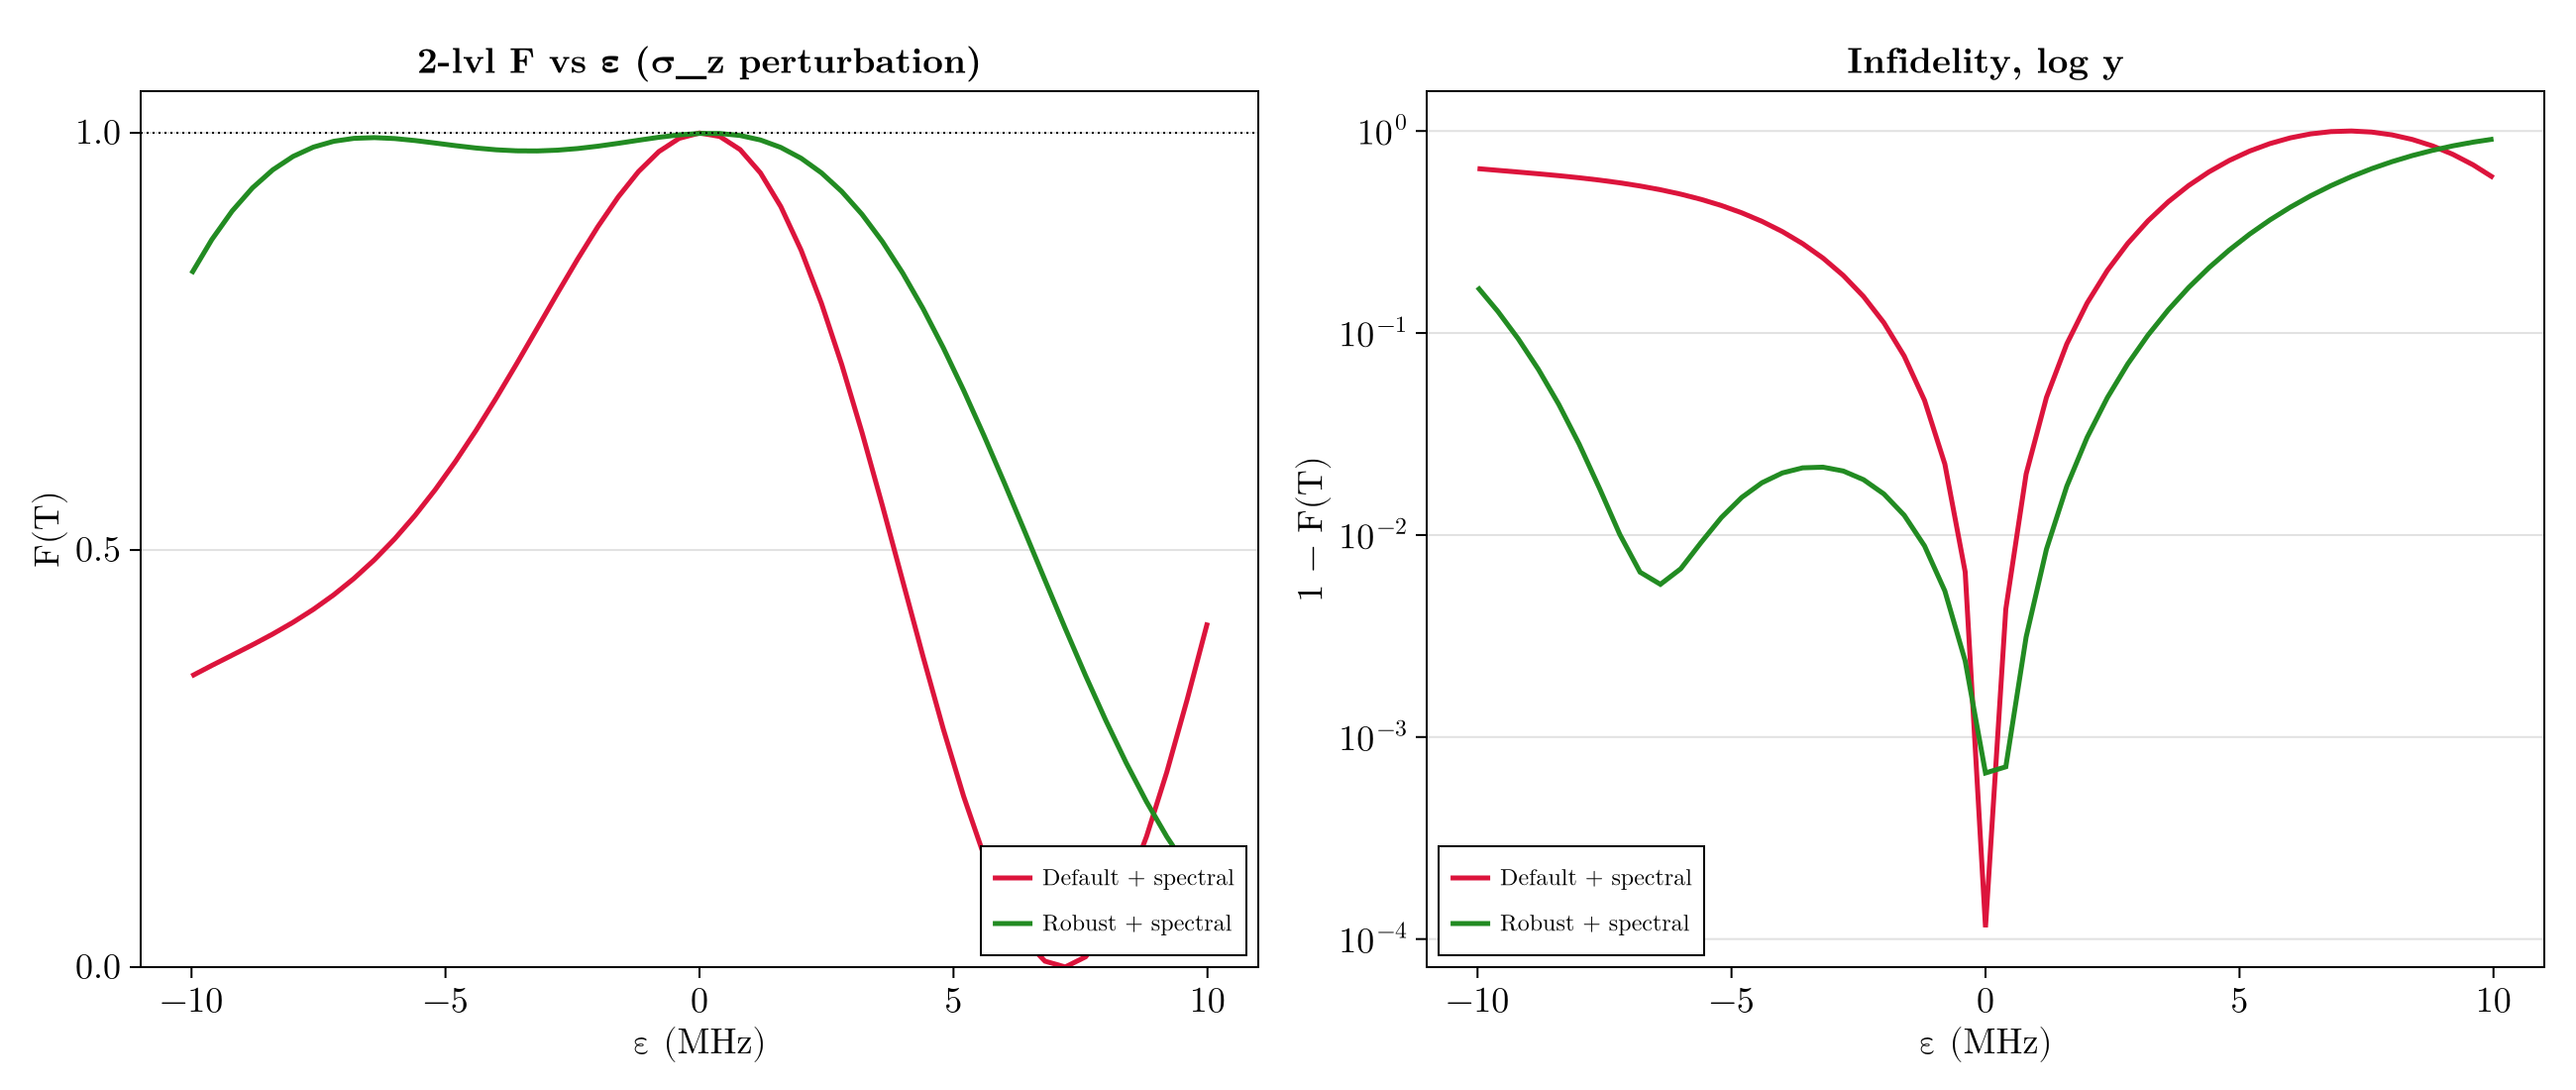

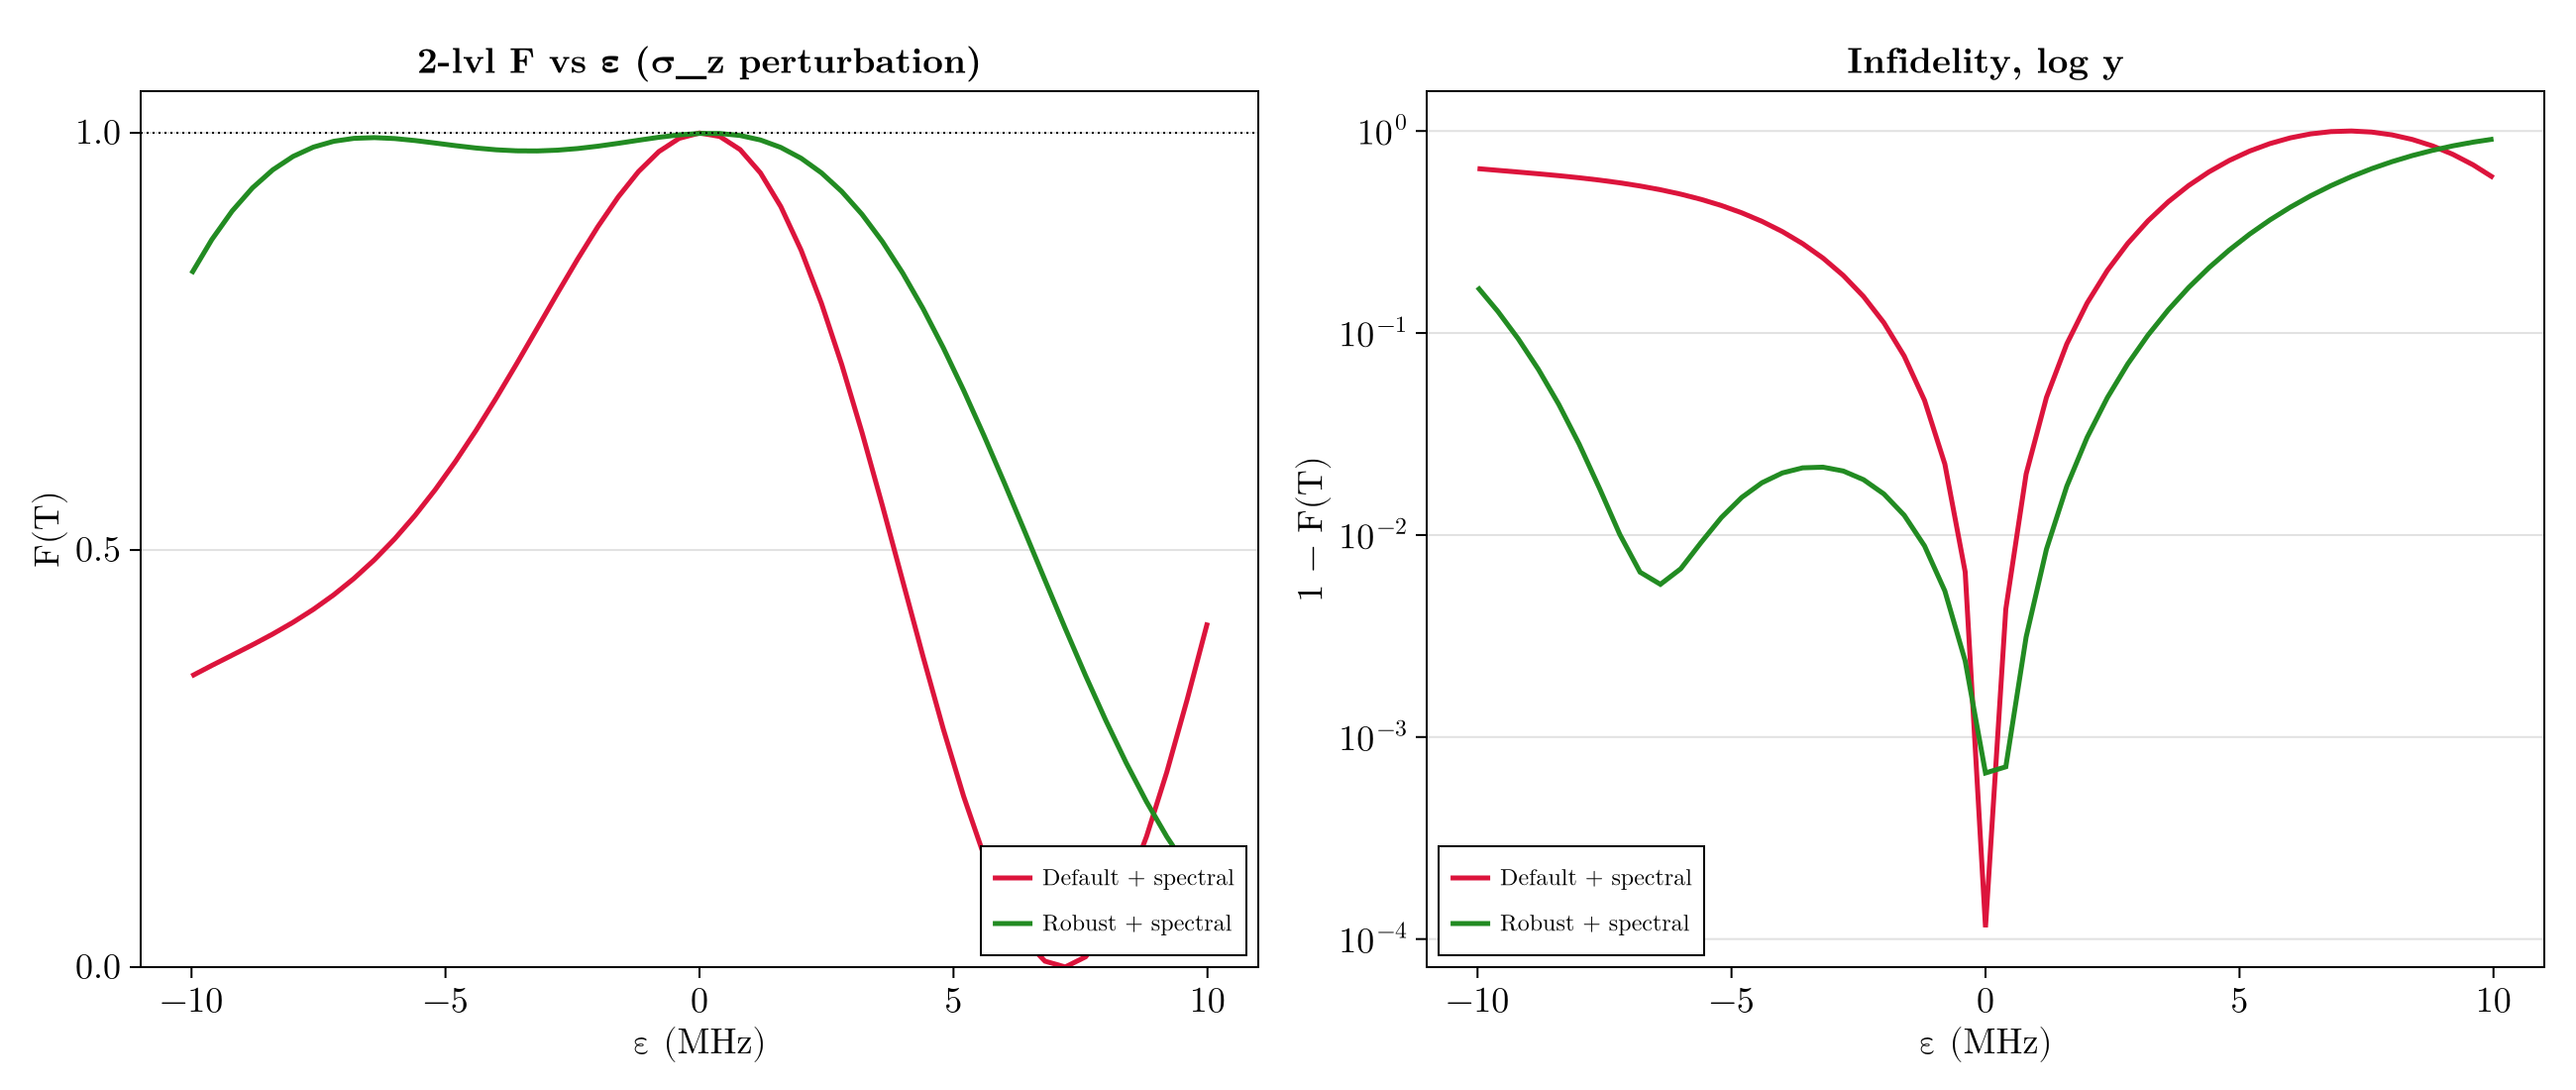

In [11]:
fig = Figure(size = (1300, 550), fontsize = 18)
ax_F  = Axis(fig[1, 1]; xlabel = "ε (MHz)", ylabel = "F(T)",
    title = "2-lvl F vs ε (σ_z perturbation)")
ax_inf = Axis(fig[1, 2]; xlabel = "ε (MHz)", ylabel = "1 − F(T)",
    yscale = log10, title = "Infidelity, log y")

for (lbl, F, c) in [
        ("Default + spectral", F2_dp, :crimson),
        ("Robust + spectral",  F2_rp, :forestgreen),
    ]
    lines!(ax_F,   εs_MHz, F; color = c, linewidth = 2.5, label = lbl)
    lines!(ax_inf, εs_MHz, max.(1 .- F, 1e-12); color = c, linewidth = 2.5, label = lbl)
end
hlines!(ax_F, [1.0]; color = :black, linestyle = :dot, linewidth = 1)
ylims!(ax_F, 0, 1.05)
axislegend(ax_F;   position = :rb, labelsize = 12)
axislegend(ax_inf; position = :lb, labelsize = 12)
display(fig)
save(joinpath(@__DIR__, "spectral_F_vs_eps_2lvl.png"), fig; px_per_unit = 4)
fig


## F and leakage vs ε (3-lvl Duffing, V = n̂)

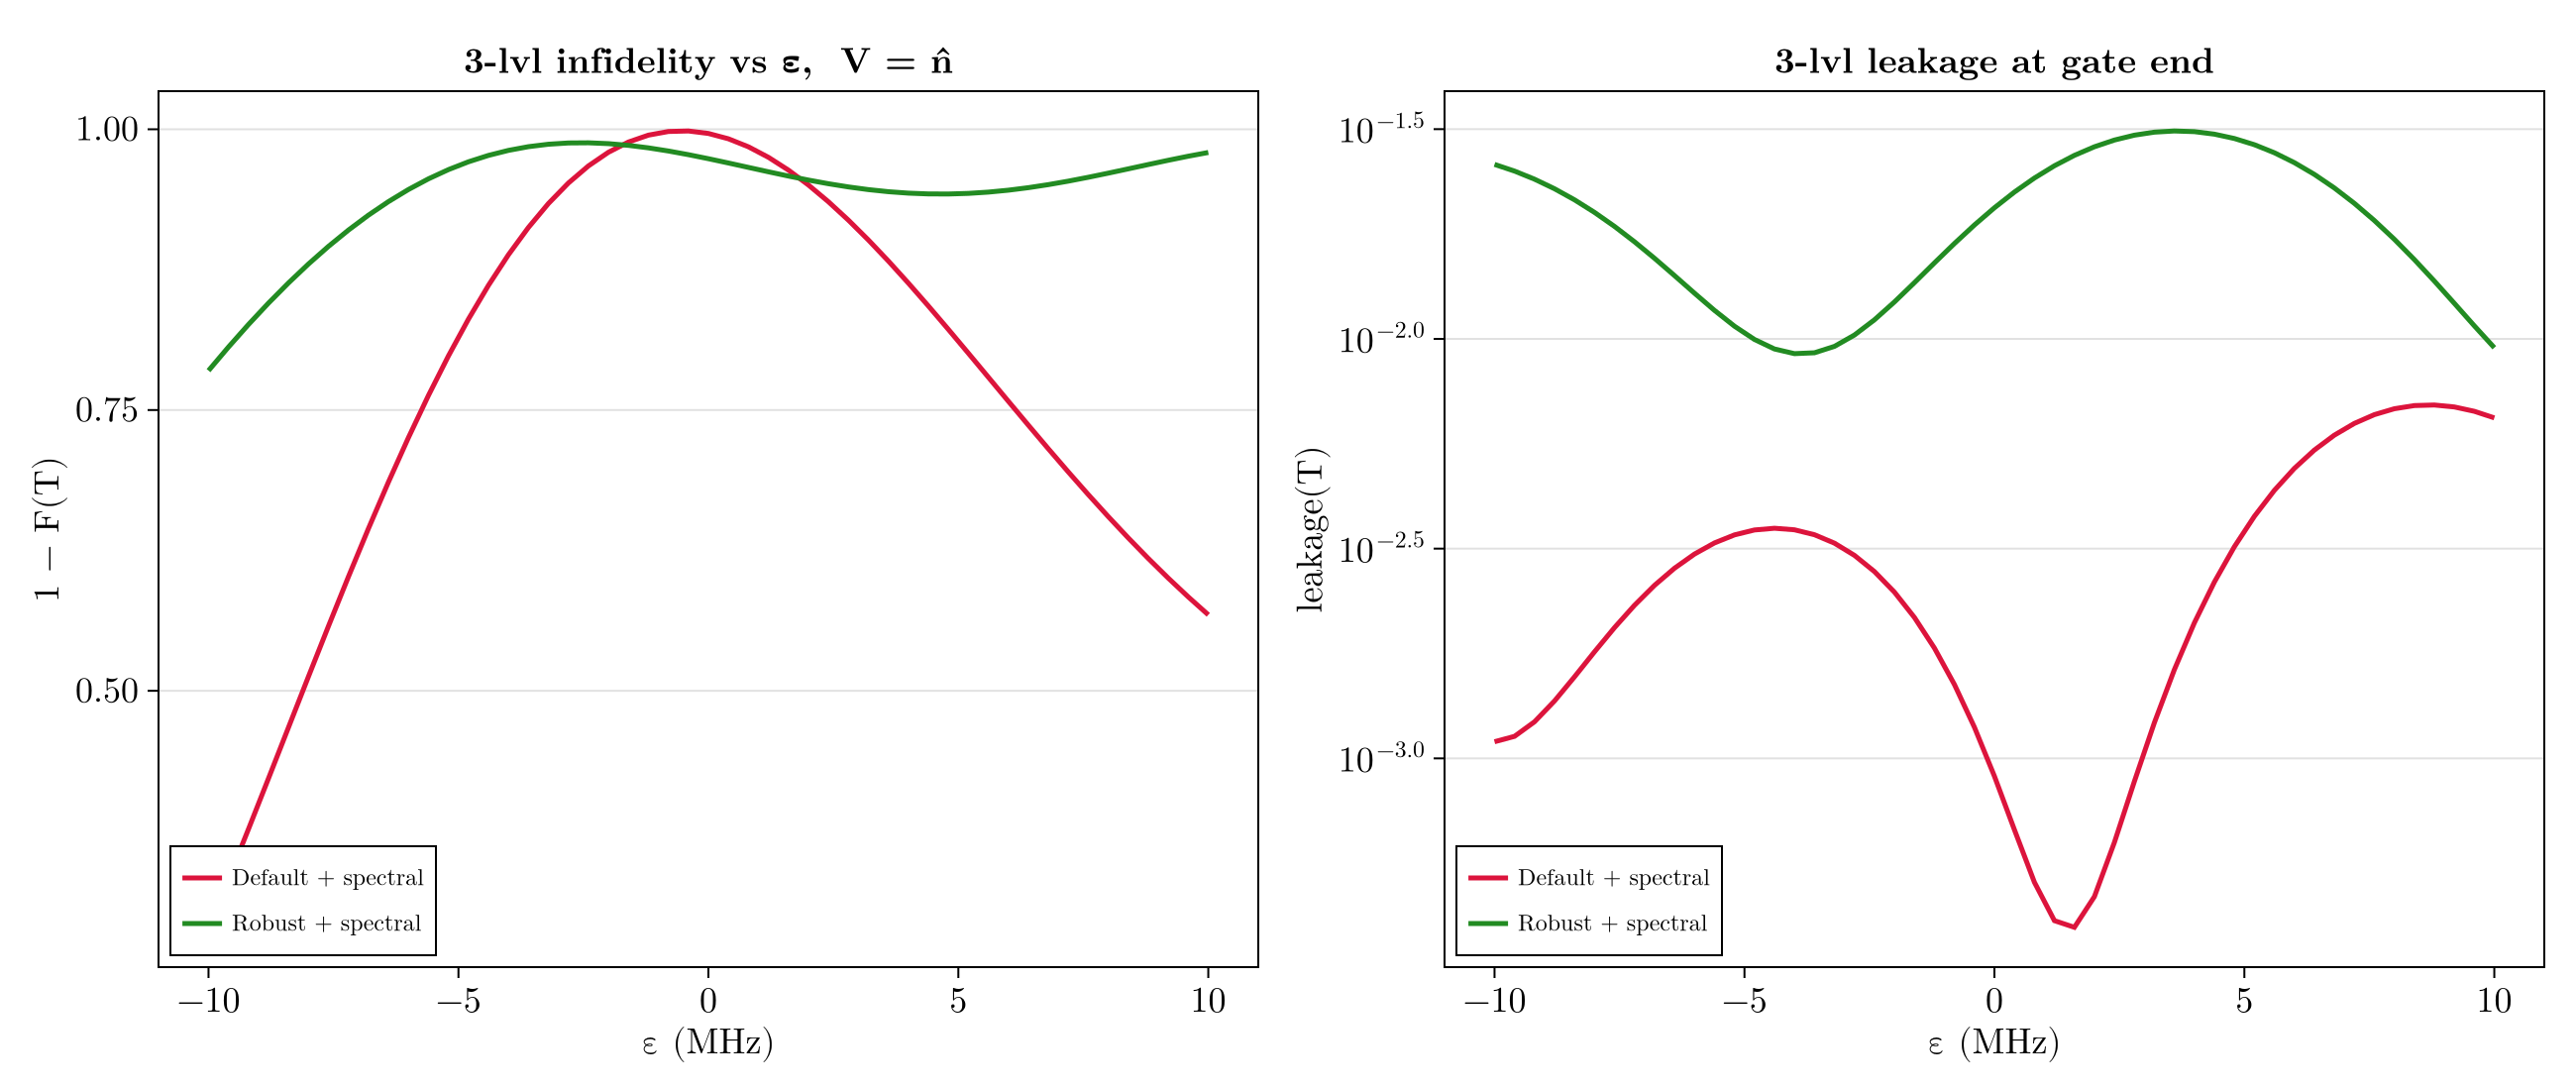

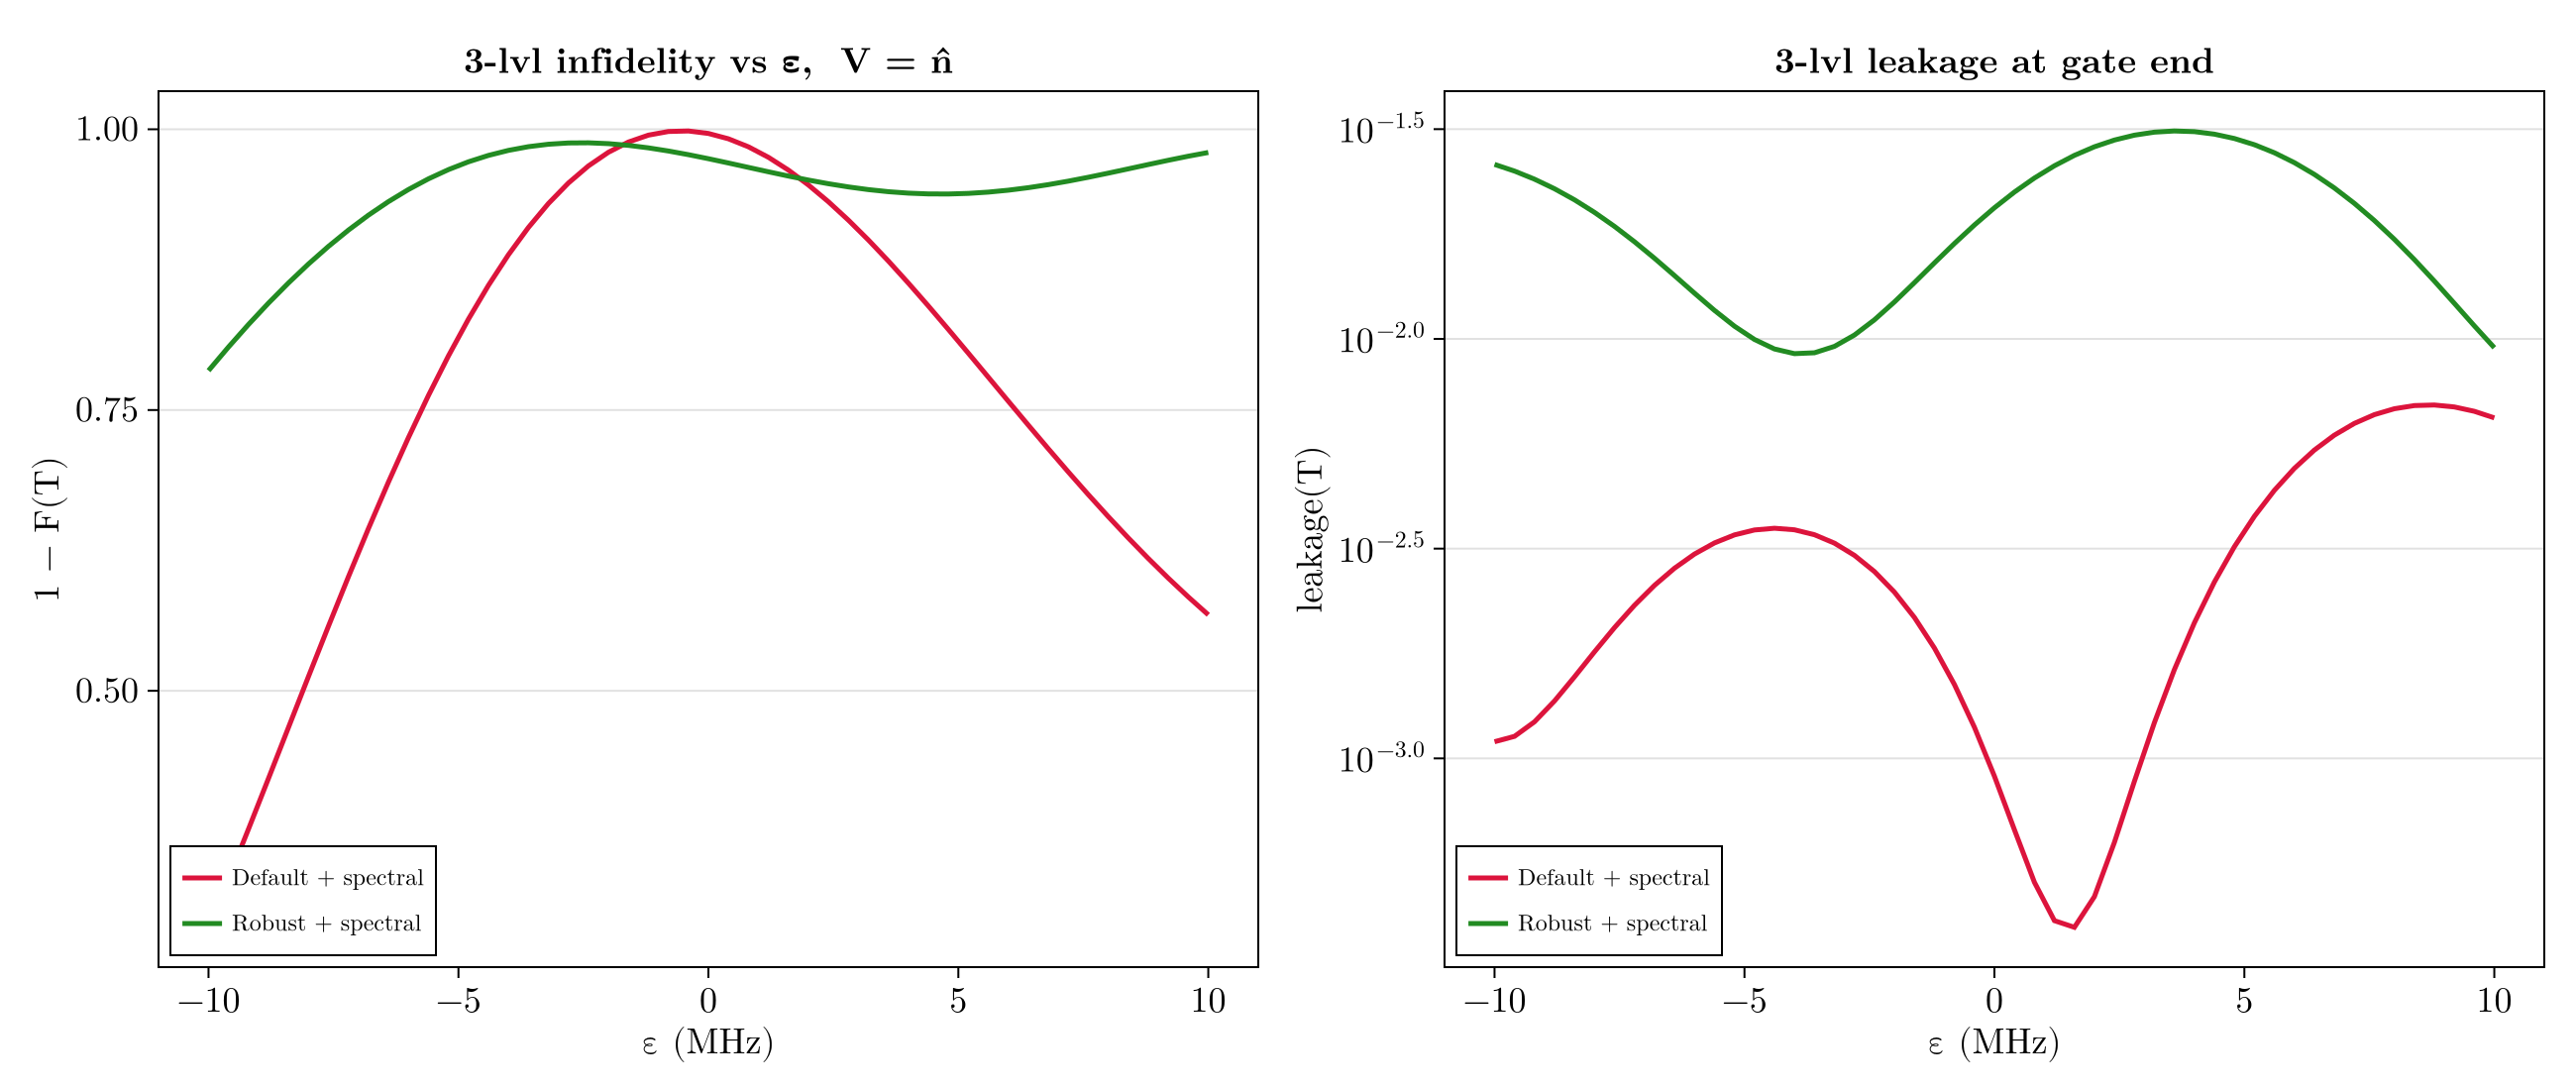

In [14]:
fig = Figure(size = (1300, 550), fontsize = 18)
ax_F = Axis(fig[1, 1]; xlabel = "ε (MHz)", ylabel = "1 − F(T)", title = "3-lvl infidelity vs ε,  V = n̂")
ax_L = Axis(fig[1, 2]; xlabel = "ε (MHz)", ylabel = "leakage(T)",
    yscale = log10, title = "3-lvl leakage at gate end")

for (lbl, F, L, c) in [
        ("Default + spectral", F3_dp, L3_dp, :crimson),
        ("Robust + spectral",  F3_rp, L3_rp, :forestgreen),
    ]
    lines!(ax_F, εs_MHz, max.(F, 1e-12);
        color = c, linewidth = 2.5, label = lbl)
    lines!(ax_L, εs_MHz, max.(L, 1e-12);
        color = c, linewidth = 2.5, label = lbl)
end
axislegend(ax_F; position = :lb, labelsize = 12)
axislegend(ax_L; position = :lb, labelsize = 12)
display(fig)
save(joinpath(@__DIR__, "spectral_F_L_vs_eps_3lvl.png"), fig; px_per_unit = 4)
fig


## Summary table

In [13]:
mid = (length(εs) + 1) ÷ 2
@printf("\n%-24s | F_2lvl(0)  | F_3lvl(0)  | L_3lvl(0)  | |Ω̂(η)|\n", "pulse")
@printf("%s\n", "-"^85)
for (lbl, traj, _) in panels
    F2 = honest_F_2lvl(traj)
    F3, L3 = F_L_3lvl(traj)
    fs_MHz, mag = envelope_spectrum(traj)
    Ω_at_η = mag[argmin(abs.(fs_MHz .- abs(η_MHz)))]
    @printf("%-24s | %.6f   | %.6f   | %.3e   | %.3e\n",
        lbl, F2, F3, L3, Ω_at_η)
end


pulse                    | F_2lvl(0)  | F_3lvl(0)  | L_3lvl(0)  | |Ω̂(η)|
-------------------------------------------------------------------------------------
Default + spectral       | 0.999886   | 0.996256   | 9.068e-04   | 3.662e-02
Robust + spectral        | 0.999336   | 0.973782   | 2.054e-02   | 2.031e-01
